In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import math
import warnings
import pymc as pm
import arviz as az
import emcee
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- UQ & prior ----------
sigma_obs = 1e-1
NS_sample = 16
EPS_VAR   = 1e-6     # sàn nhỏ để tránh var_eff ~ 0 (ổn định log)
PI2       = 2.0 * math.pi


cpu


In [2]:
L = 1 # domain
dt = 1 # time step
T = 1473
nt = T/dt
T_MIN = 22.
T_MAX = 90.
CP_MIN = 800.
CP_MAX = 1100.
PS_MIN = 2350.
PS_MAX = 2450.

point_list = np.array([[0.06,0.61],
                      [0.59,0.01],
                      [0.11,0.31],
                      [0.42,0.15],
                      [1.1,0.13],
                      [0.2,1.34]],dtype=np.float32)

#FW model architecture

In [6]:
# ========= Your spectral block (giữ nguyên) =========
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.weights = nn.Parameter(
            torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat) * 0.1
        )

    def compl_mul1d(self, input, weights):
        return torch.einsum("bcn,con->bon", input, weights)

    def forward(self, x):
        B, C, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        out_ft = torch.zeros(B, self.out_channels, x_ft.shape[-1],
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes] = self.compl_mul1d(x_ft[:, :, :self.modes], self.weights)
        x = torch.fft.irfft(out_ft, n=N, dim=-1)
        return x

# ========= Bayesian 1x1 Conv (variational) =========
class BayesianConv1d(nn.Module):
    """
    1x1 conv variational theo kênh:
      out[b, o, n] = sum_c W[o,c] * x[b,c,n] + b[o]
    W ~ N(mu, sigma^2), sigma = softplus(rho).
    Trả về: out, kl_div (so với prior N(0,1)).
    """
    def __init__(self, in_channels, out_channels, bias=True, prior_mu=0.0, prior_sigma=1.0):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.prior_mu = prior_mu
        self.prior_sigma = prior_sigma

        # Posterior q(W): dùng ma trận [out,in] (không có trục 1 chiều)
        self.weight_mu  = nn.Parameter(torch.empty(out_channels, in_channels))
        self.weight_rho = nn.Parameter(torch.empty(out_channels, in_channels))
        if bias:
            self.bias_mu  = nn.Parameter(torch.empty(out_channels))
            self.bias_rho = nn.Parameter(torch.empty(out_channels))
        else:
            self.register_parameter('bias_mu', None)
            self.register_parameter('bias_rho', None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight_mu, a=math.sqrt(5))
        nn.init.constant_(self.weight_rho, -4.0)  # sigma nhỏ ban đầu
        if self.bias_mu is not None:
            bound = 1. / max(1, self.in_channels) ** 0.5
            nn.init.uniform_(self.bias_mu, -bound, bound)
            nn.init.constant_(self.bias_rho, -4.0)

    @staticmethod
    def _softplus(x):
        return F.softplus(x)

    def kl_divergence(self, w_mu, w_sigma, prior_mu, prior_sigma):
        # KL(q||p) từng phần tử Gaussian
        term1 = torch.log(prior_sigma / (w_sigma + 1e-12))
        term2 = (w_sigma**2 + (w_mu - prior_mu)**2) / (2 * (prior_sigma**2))
        kl = (term1 + term2 - 0.5).sum()
        return kl

    def forward(self, x):
        """
        x: [B, C_in, N]
        out: [B, C_out, N]
        """
        B, C, N = x.shape
        device = x.device

        # Sample W, b
        w_sigma = self._softplus(self.weight_rho)
        W = self.weight_mu + w_sigma * torch.randn_like(self.weight_mu, device=device)

        if self.bias_mu is not None:
            b_sigma = self._softplus(self.bias_rho)
            b = self.bias_mu + b_sigma * torch.randn_like(self.bias_mu, device=device)
        else:
            b = None

        # 1x1 conv theo kênh: giữ nguyên N
        # (broadcast b theo N)
        out = torch.einsum('bcn,oc->bon', x, W)
        if b is not None:
            out = out + b.view(1, -1, 1)

        # KL cho W và b
        kl = self.kl_divergence(self.weight_mu, w_sigma,
                                torch.tensor(self.prior_mu, device=device),
                                torch.tensor(self.prior_sigma, device=device))
        if self.bias_mu is not None:
            kl = kl + self.kl_divergence(self.bias_mu, self._softplus(self.bias_rho),
                                         torch.tensor(self.prior_mu, device=device),
                                         torch.tensor(self.prior_sigma, device=device))
        return out, kl

import math

# ========= FNO với Bayesian head xuất (mu, logvar) =========
class FNO1d_Bayes(nn.Module):
    def __init__(self, in_channels, out_channels, modes=12, width=64, prior_sigma=1.0):
        super().__init__()
        self.out_channels = out_channels
        self.fc0 = nn.Conv1d(in_channels, width, 1)  # [B, C_in, N]
        self.conv1 = SpectralConv1d(width, width, modes)
        self.conv2 = SpectralConv1d(width, width, modes)
        self.w1 = nn.Conv1d(width, width, 1)
        self.w2 = nn.Conv1d(width, width, 1)
        self.fc1 = nn.Conv1d(width, 128, 1)

        # Bayesian head: xuất 2*C_out để tách mu và logvar
        self.fc2_bayes = BayesianConv1d(128, 2*out_channels, prior_sigma=prior_sigma)

    def forward(self, x):
        """
        Input:  x [B, C_in, N]
        Output: mu [B, C_out, N], logvar [B, C_out, N], kl (scalar tensor)
        """
        x = self.fc0(x)
        x1 = self.conv1(x); x2 = self.w1(x); x = F.gelu(x1 + x2)
        x1 = self.conv2(x); x2 = self.w2(x); x = F.gelu(x1 + x2)
        x = F.gelu(self.fc1(x))

        out, kl = self.fc2_bayes(x)  # [B, 2*C_out, N]
        mu, logvar = torch.split(out, self.out_channels, dim=1)
        # Stabilize logvar (optional clamp)
        logvar = torch.clamp(logvar, min=-15.0, max=-10.0)
        return mu, logvar, kl

# ========= Predictive distribution qua MC sampling ========

    @torch.no_grad()
    def mc_predict(model, x, T=20):
        """
        Inference T sample ( each sampe is drawned from p(w|D)).
        Return:
          pred_mean  [B,C,N]        = E_q[μ]
          ale_var    [B,C,N]        = E_q[σ²]
          epi_var    [B,C,N]        = Var_q[μ]
          total_var  [B,C,N]        = ale_var + epi_var
        """
        mus = []
        vars_ = []
        for _ in range(T):
            mu, logvar, _ = model(x)
            mus.append(mu)
            vars_.append(torch.exp(logvar))
        mus = torch.stack(mus, dim=0)  # [T,B,C,N]
        vars_ = torch.stack(vars_, dim=0)

        pred_mean = mus.mean(0)
        ale_var = vars_.mean(0)
        epi_var = mus.var(0, unbiased=False)
        total_var = ale_var + epi_var
        return pred_mean, ale_var, epi_var, total_var

def standardize_tensor(tensor, T_min=22., T_max=100.):
  """Standardizes a tensor to [0, 1] using min-max scaling."""
  return (tensor - T_min) / (T_max - T_min)

def destandardize_tensor(tensor, T_min = 22., T_max = 100.):
  """Destandardizes a tensor from [0, 1] to its original range."""
  return tensor * (T_max - T_min) + T_min


In [10]:
INPUT = 6
OUTPUT = 1473
model_path = './pretrained/fno1d_bayes_model.pt'
fw_model = FNO1d_Bayes(in_channels=INPUT, out_channels=OUTPUT, modes=4, width=256, prior_sigma=1e-1).to(device)
if torch.cuda.is_available():
  fw_model.load_state_dict(torch.load(model_path)['model_state'])
else:
  fw_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu'))['model_state'])

def predict_single_sample_mc(model, sample_x, device, T_MIN=22., T_MAX=90.):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        # Add a batch dimension and move to the correct device
        sample_x = sample_x.unsqueeze(0).to(device)

        mean_pred,_, _, var_pred = FNO1d_Bayes.mc_predict(model, sample_x, T=NS_sample)
        mean_pred = mean_pred.cpu()
        var_pred = var_pred.cpu()

        mean = destandardize_tensor(mean_pred, T_MIN, T_MAX)
        var = var_pred*(T_MAX - T_MIN)**2
    return mean.squeeze(0).permute(1, 0).numpy(), var.squeeze(0).permute(1, 0).numpy()

def Surrogate(model, point_list, params):
    """
    Chạy surrogate để dự báo nhiệt độ tại các điểm/ thời điểm cần quan sát.
    - Chuẩn hóa đầu vào giống lúc train.
    - Chỉ trả về các vị trí có mask temperature_data_mask.
    """
    params_tensor = torch.tensor(params, dtype=torch.float32)

    new_point_list = []
    for i in range(point_list.shape[0]):
        p = torch.tensor(point_list[i], dtype=torch.float32)
        # (2,) + (4,) -> (6,)
        combined = torch.cat([p, params_tensor], dim=0)
        new_point_list.append(combined)

    X_BI_test = torch.stack(new_point_list)      # (n_points, 6)
    X = X_BI_test.permute(1, 0).to(device)       # (6, n_points)

    # Chuẩn hóa theo quy ước khi train
    X[0:2, :] = X[0:2, :] / L
    X[2:3, :] = standardize_tensor(X[2:3, :], 0.8, 2.5)
    X[3:4, :] = standardize_tensor(X[3:4, :], 1.1, 2.5)
    X[4:5, :] = standardize_tensor(X[4:5, :], PS_MIN, PS_MAX)
    X[5:6, :] = standardize_tensor(X[5:6, :], CP_MIN, CP_MAX)
    # Dự báo
    # y_pred_ensemble, var_pred_ensemble shape [6,1473]
    y_pred_ensemble, var_pred_ensemble = predict_single_sample_mc(model, X, device=device)
    # Drawn random y from distribution of y prediction:
    Z = 0.5*np.random.randn(NS_sample, 1, 1) 
    y_std = np.sqrt(var_pred_ensemble)
    #y_samples shape (NS_sample, 6, 1473)
    y_samples = y_pred_ensemble + y_std * Z


    y_samples = y_samples.reshape(y_samples.shape[0], -1)
    y_samples_masked = y_samples[:, temperature_data_mask]

    return y_samples_masked

In [12]:
# ---------- Prior trong không gian z ----------
def log_prior(z):
    z = np.asarray(z, dtype=float)
    if np.any(np.abs(z) > 5):
        return -np.inf
    # prior N(0,1) độc lập từng chiều (bỏ hằng số)
    return -0.5 * np.sum(z**2)


# ---------- Likelihood ----------
def log_likelihood_ELik(z):

    params = prior_mean + np.asarray(z) * prior_std

    # Bounds 4 tham số vật lý
    if (np.any(params < lower_bounds)) or (np.any(params > upper_bounds)):
        return -np.inf
    # y_pred_ensemble and var_pred_ensemble will be (NS_sample, N_masked_points)
    y_pred_ensemble = Surrogate(fw_model, point_list, params)

    S, N = y_pred_ensemble.shape
    if N != u_obs.shape[0]:
        return -np.inf

    # Tính log-likelihood cho từng s
    loglikes = np.empty(S)
    var = np.maximum(sigma_obs**2, EPS_VAR)
    for s in range(S):
        resid = u_obs - y_pred_ensemble[s]   # (N,)
        if not np.all(np.isfinite(resid)):
            return -np.inf
        ll_s = -0.5 * (np.sum(resid*resid / var) + N*np.log(PI2*var))
        loglikes[s] = ll_s

    # Mixture posterior: log-mean-exp
    m = np.max(loglikes)
    loglik = m + np.log(np.mean(np.exp(loglikes - m)))

    return float(loglik)

def log_posterior(z):
    """
    log posterior = log prior + log likelihood.
    Nếu prior = -inf hoặc likelihood = -inf => trả -inf.
    """
    lp = log_prior(z)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood_ELik(z)
    if not np.isfinite(ll):
        return -np.inf
    return float(lp + ll)

#Preparing Experimental Data

In [14]:
experimanrtal_data_path = "D:/PhD/01.Thermal/TED/Experimental/TED_Temperature.xlsx"
df = pd.read_excel(experimanrtal_data_path)
temperature_columns = df.columns[2:]
temperature_data = df[temperature_columns].T.values#[:2]
temperature_data_mask = ~np.isnan(temperature_data)
temperature_data_mask = temperature_data_mask.flatten()
time_points = df['Time'] # Sau dùng để visulization



print(f'temperature_data shape:{temperature_data.shape}')
print(f'temperature_data_mask shape:{temperature_data_mask.shape}')
print(df.head())

temperature_data shape:(6, 1473)
temperature_data_mask shape:(8838,)
        Time  STT  TED1210_TEM_05  TED1219_TEM_05  TED1250_TEM_01  \
0 2009-07-08    1             NaN             NaN             NaN   
1 2009-07-09    2             NaN             NaN             NaN   
2 2009-07-10    3             NaN             NaN             NaN   
3 2009-07-11    4             NaN             NaN             NaN   
4 2009-07-12    5             NaN             NaN             NaN   

   TED1251_TEM_01  TED1253_TEM_01  TED1258_TEM_01  
0             NaN       21.494342             NaN  
1       21.534905       21.491602             NaN  
2       21.539591       21.497382             NaN  
3       21.550029       21.504905             NaN  
4       21.561187       21.516124             NaN  


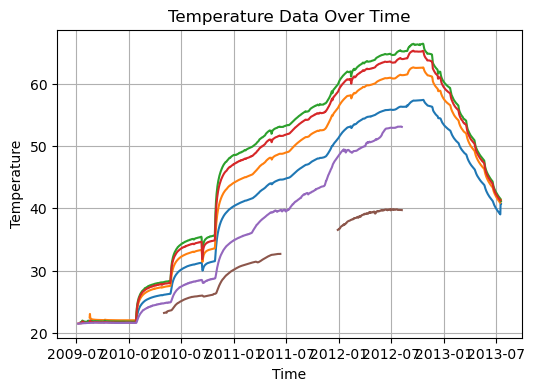

In [16]:
plt.figure(figsize=(6, 4))
for i in range(temperature_data.shape[0]):
    plt.plot(df['Time'], temperature_data[i, :], label=f'Temperature {i+1}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title('Temperature Data Over Time')
plt.grid(True)
plt.show()

In [36]:

# ---------- Prior thông số vật lý (bạn đã khai báo ở cuối – giữ nguyên) ----------
PS_mean = 2420
PS_std  = 40.0
CP_mean = 978
CP_std  = 70.0

prior_mean   = np.array([1.31, 1.5, PS_mean, CP_mean], dtype=float)
prior_std    = np.array([2.5e-1, 2.5e-1, PS_std,  CP_std ], dtype=float)
lower_bounds = np.array([0.8,  1.1,  PS_MIN,  CP_MIN], dtype=float)
upper_bounds = np.array([2.0,  2.5,  2500,  CP_MAX], dtype=float)

# ---------- Dữ liệu quan sát ----------
u_obs = temperature_data.flatten()[temperature_data_mask]
# ---------- Thiết lập MCMC ----------
n_params      = 4
n_walkers     = 8 * n_params       # quy tắc emcee: >= 2*ndim; dùng nhiều hơn để ổn định
n_steps       = 1_000
burn_in       = 1_00
thin_step     = 10

In [ ]:

# Khởi tạo z ~ N(0, I) (tất cả walker ở vùng có prior khối lượng lớn)
rng = np.random.default_rng(42)
initial_z = 0.2*rng.normal(0.0, 1.0, size=(n_walkers, n_params))

# Tổ hợp move giúp trộn tốt hơn nếu có tương quan mạnh
moves = [
    (emcee.moves.StretchMove(a=2.0),         0.6),
    (emcee.moves.DEMove(),                   0.3),
    (emcee.moves.DESnookerMove(),   0.1), # Removed gamma=1.0
]

sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior, moves=moves)

print("🔁 Running MCMC ...")
t_start = time.time()
sampler.run_mcmc(initial_z, n_steps, progress=True)
t_end = time.time()
print(f"✅ Done in {t_end - t_start:.2f}s")


🔁 Running MCMC ...


  4%|███▏                                                                          | 41/1000 [08:18<3:23:22, 12.72s/it]

Acceptance (per walker): [0.051 0.071 0.087 0.091 0.094 0.083 0.071 0.087 0.083 0.106 0.106 0.094
 0.098 0.087 0.091 0.075 0.114 0.087 0.087 0.098 0.098 0.079 0.118 0.106
 0.055 0.094 0.087 0.102 0.087 0.114 0.071 0.102]
🧹 Số walker bị loại bỏ: 0 / 32
----- Posterior summary -----
Param θ1: Mean = 1.219008e+00,  SD = 2.178045e-02
Param θ2: Mean = 1.576973e+00,  SD = 4.866803e-02
Param θ3: Mean = 2.441998e+03,  SD = 7.552260e+00
Param θ4: Mean = 1.085725e+03,  SD = 2.310564e+01


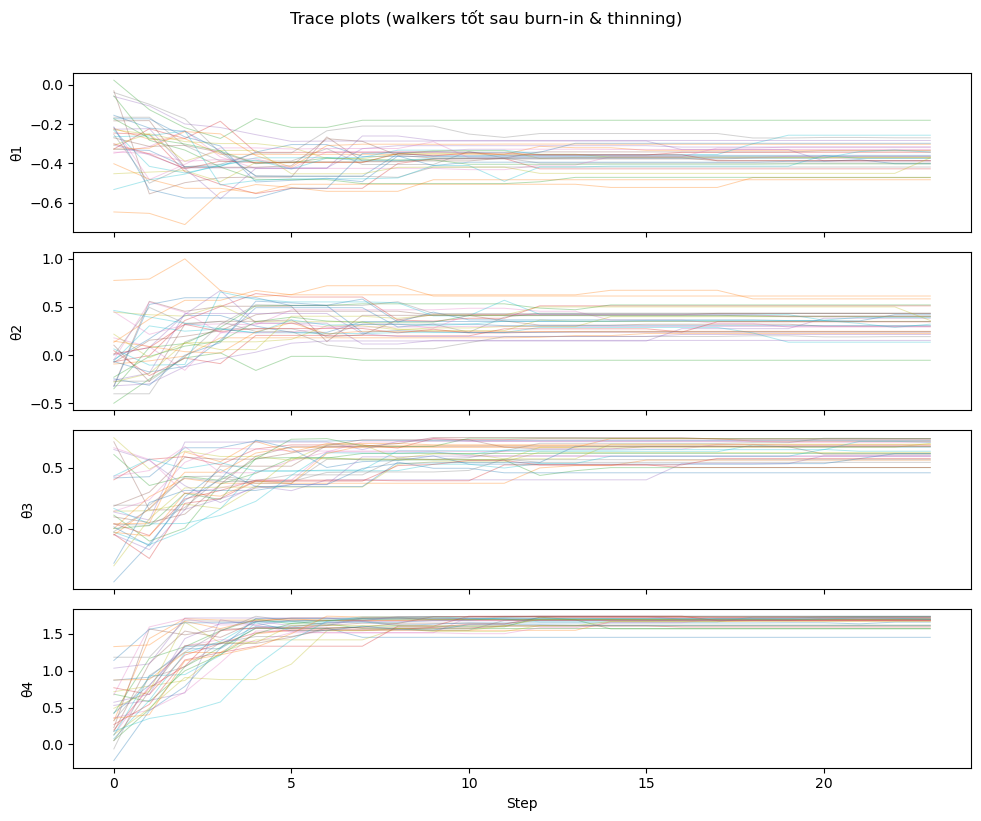

In [34]:
# ---------- Chẩn đoán nhanh ----------
acceptance_fraction = sampler.acceptance_fraction
print("Acceptance (per walker):", np.round(acceptance_fraction, 3))

threshold = 1e-3                       # loại walker gần như không chấp nhận
burn_in = 10
good_walkers = np.where(acceptance_fraction >= threshold)[0]
bad_walkers  = np.where(acceptance_fraction <  threshold)[0]
print(f"🧹 Số walker bị loại bỏ: {len(bad_walkers)} / {n_walkers}")

# Lấy chuỗi sau burn-in + thinning, chỉ giữ walker tốt
chain_all = sampler.get_chain(discard=burn_in, thin=thin_step, flat=False)   # (steps, walkers, params)
chain_good = chain_all[:, good_walkers, :]                                   # (steps, good_walkers, params)

# ---------- Đưa về không gian tham số gốc để báo cáo ----------
samples_z = chain_good.reshape(-1, n_params)

# 4 tham số vật lý
samples_params = samples_z * prior_std + prior_mean


# ---------- Thống kê hậu nghiệm ----------
mean_params = np.mean(samples_params, axis=0)
std_params  = np.std(samples_params, axis=0, ddof=1)

print("----- Posterior summary -----")
for i in range(samples_params.shape[1]):
    print(f"Param θ{i+1}: Mean = {mean_params[i]:.6e},  SD = {std_params[i]:.6e}")


# ---------- Trace plots ----------
param_names = [f"θ{i+1}" for i in range(samples_params.shape[1])]
fig, axes = plt.subplots(n_params, figsize=(10, 2.0 * n_params), sharex=True)
for j in range(n_params):
    for w in range(chain_good.shape[1]):
        axes[j].plot(chain_good[:, w, j], alpha=0.35, lw=0.7)
    axes[j].set_ylabel(param_names[j])
axes[-1].set_xlabel("Step")
plt.suptitle("Trace plots (walkers tốt sau burn-in & thinning)", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\kuanghiu\anaconda3\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (32) than draws (15). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


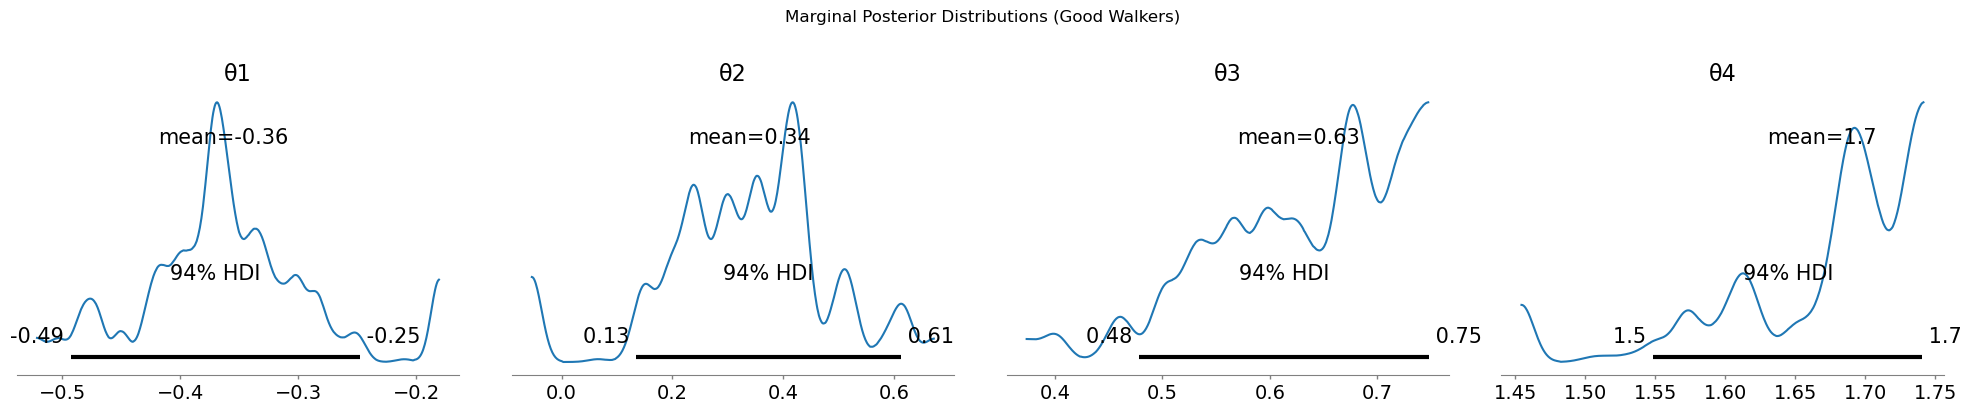

In [28]:
# Plot marginal posterior distributions for good walkers

# Extract the flattened samples from the good chains
# samples_z is already flattened and contains only good walkers' samples after discard and thin
# Reshape samples_z back to (n_samples, n_good_walkers, n_params) for az.from_dict
n_samples = chain_good.shape[0]
n_good_walkers = chain_good.shape[1]
samples_reshaped = chain_good  # Use chain_good directly

# Create a dictionary in the format expected by az.from_dict
# Transpose the data for each parameter to be (n_good_walkers, n_samples)
posterior_dict = {param_names[i]: samples_reshaped[:, :, i].T for i in range(n_params)}


idata_good_walkers = az.from_dict(
    posterior=posterior_dict,
    coords={"chain": np.arange(n_good_walkers), "draw": np.arange(n_samples)},
    dims={"θ": ["param"]} # Define a dimension for the parameters if needed
)

az.plot_posterior(idata_good_walkers, figsize=(20, n_params))
plt.suptitle("Marginal Posterior Distributions (Good Walkers)", y=1.02)
plt.tight_layout()
plt.show()

In [30]:
import arviz as az
import matplotlib.pyplot as plt

# Plot marginal densities with 94% HDI
az.plot_density(
    [idata_params],
    var_names=param_names_real,
    hdi_prob=0.94
)

plt.suptitle("Posterior Marginal Densities (94% HDI)", y=1.02)
plt.show()


NameError: name 'idata_params' is not defined

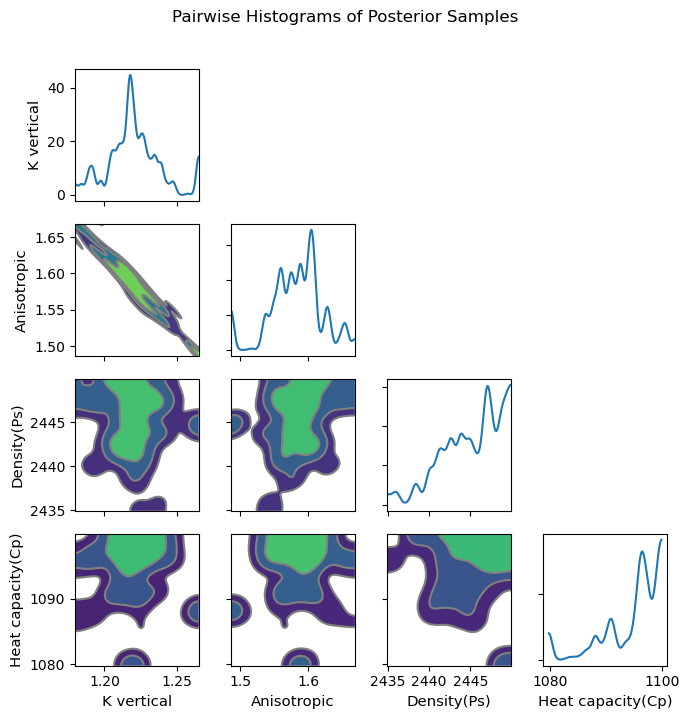

In [32]:
import arviz as az
import matplotlib.pyplot as plt

param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"]

posterior_params_dict = {param_names_real[i]: samples_params[:, i].reshape(1, -1) for i in range(samples_params.shape[1])}

idata_params = az.from_dict(
    posterior=posterior_params_dict,
    coords={"chain": [0], "draw": np.arange(samples_params.shape[0])},
    dims={"K vertical": [], "Anisotropic": [], "Density(Ps)": [], "Heat capacity(Cp)": []}
)

# Plot pairwise distributions using plot_pair
az.plot_pair(idata_params, kind='kde', marginals=True, textsize=10, figsize=(7, 7))
plt.suptitle("Pairwise Histograms of Posterior Samples", y=1.02)
plt.tight_layout()
plt.show()

In [1114]:
posterior_params_dict
# Điều kiện lọc dựa trên K vertical
mask_lt = (posterior_params_dict['K vertical'][0] <= 1.25) & (posterior_params_dict['K vertical'][0] >= 1.1)
mask_ge = (posterior_params_dict['K vertical'][0] > 1.25) & (posterior_params_dict['K vertical'][0] <= 1.35)


# Tạo dict mới
posterior_params_dict_1 = {k: v[:, mask_lt] for k, v in posterior_params_dict.items()}
posterior_params_dict_2 = {k: v[:, mask_ge] for k, v in posterior_params_dict.items()}


print("Số mẫu K vertical < 1.2:", posterior_params_dict_1['K vertical'].shape[1])
print("Số mẫu K vertical >= 1.2:", posterior_params_dict_2['K vertical'].shape[1])

Số mẫu K vertical < 1.2: 2700
Số mẫu K vertical >= 1.2: 23850


In [1116]:
samples_params_1 = np.vstack([v for v in posterior_params_dict_1.values()])
samples_params_2 = np.vstack([v for v in posterior_params_dict_2.values()])

In [1118]:
# ---------- Thống kê hậu nghiệm ----------
mean_params = np.mean(samples_params_1, axis=1)
std_params  = np.std(samples_params_1, axis=1, ddof=1)
mean_sigma  = float(np.mean(samples_sigma_obs))
std_sigma   = float(np.std(samples_sigma_obs, ddof=1))

print("----- Posterior summary cluster 1-----")
for i in range(n_phys_params):
    print(f"Param θ{i+1}: Mean = {mean_params[i]:.6e},  SD = {std_params[i]:.6e}")
print(f"sigma_obs: Mean = {mean_sigma:.6f}, SD = {std_sigma:.6f}")

----- Posterior summary cluster 1-----
Param θ1: Mean = 1.229736e+00,  SD = 8.296745e-03
Param θ2: Mean = 1.709269e+00,  SD = 1.340235e-02
Param θ3: Mean = 2.395638e+03,  SD = 2.036928e+00
Param θ4: Mean = 8.488484e+02,  SD = 2.562748e+00
sigma_obs: Mean = 1.536141, SD = 0.023902


In [1120]:
# ---------- Thống kê hậu nghiệm ----------
mean_params = np.mean(samples_params_2, axis=1)
std_params  = np.std(samples_params_2, axis=1, ddof=1)
mean_sigma  = float(np.mean(samples_sigma_obs))
std_sigma   = float(np.std(samples_sigma_obs, ddof=1))

print("----- Posterior summary cluster 2-----")
for i in range(n_phys_params):
    print(f"Param θ{i+1}: Mean = {mean_params[i]:.6e},  SD = {std_params[i]:.6e}")
print(f"sigma_obs: Mean = {mean_sigma:.6f}, SD = {std_sigma:.6f}")

----- Posterior summary cluster 2-----
Param θ1: Mean = 1.323602e+00,  SD = 1.690024e-02
Param θ2: Mean = 1.452795e+00,  SD = 2.341865e-02
Param θ3: Mean = 2.403308e+03,  SD = 1.233699e+01
Param θ4: Mean = 1.024110e+03,  SD = 3.297178e+01
sigma_obs: Mean = 1.536141, SD = 0.023902


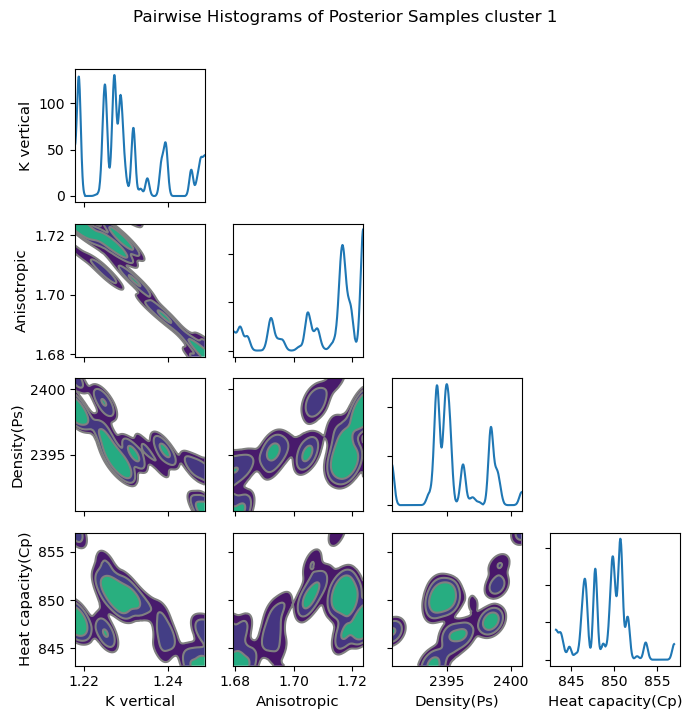

In [1122]:
import arviz as az
import matplotlib.pyplot as plt

param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"]

posterior_params_dict = {param_names_real[i]: samples_params[:, i].reshape(1, -1) for i in range(samples_params.shape[1])}

idata_params = az.from_dict(
    posterior=posterior_params_dict_1,
    coords={"chain": [0], "draw": np.arange(posterior_params_dict_1['K vertical'].shape[1])},
    dims={"K vertical": [], "Anisotropic": [], "Density(Ps)": [], "Heat capacity(Cp)": []}
)

# Plot pairwise distributions using plot_pair
az.plot_pair(idata_params, kind='kde', marginals=True, textsize=10,figsize=(7, 7))
plt.suptitle("Pairwise Histograms of Posterior Samples cluster 1", y=1.02)
plt.tight_layout()
plt.show()

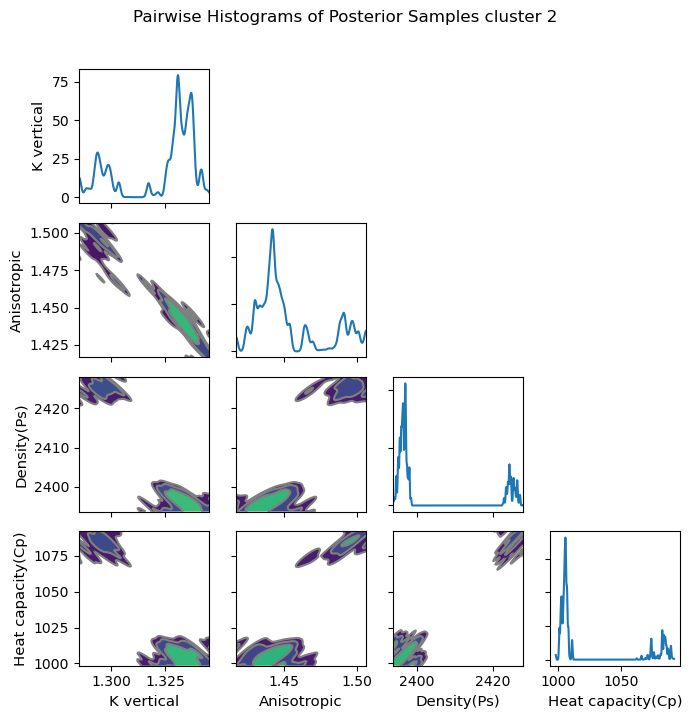

In [1123]:
import arviz as az
import matplotlib.pyplot as plt

param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"]

posterior_params_dict = {param_names_real[i]: samples_params[:, i].reshape(1, -1) for i in range(samples_params.shape[1])}

idata_params = az.from_dict(
    posterior=posterior_params_dict_2,
    coords={"chain": [0], "draw": np.arange(posterior_params_dict_2['K vertical'].shape[1])},
    dims={"K vertical": [], "Anisotropic": [], "Density(Ps)": [], "Heat capacity(Cp)": []}
)

# Plot pairwise distributions using plot_pair
az.plot_pair(idata_params, kind='kde', marginals=True, textsize=10, figsize=(7, 7))
plt.suptitle("Pairwise Histograms of Posterior Samples cluster 2", y=1.02)
plt.tight_layout()
plt.show()

In [953]:
sensor_slices = []
current_masked_index = 0
# Reshape the mask to match the original temperature_data shape (num_sensors, num_time_points)
temperature_data_mask_reshaped = temperature_data_mask.reshape(temperature_data.shape)

for i in range(temperature_data_mask_reshaped.shape[0]):
    # Count the number of True values for the current sensor in the mask
    num_masked_points_for_sensor = np.sum(temperature_data_mask_reshaped[i, :])

    # Define the slice for the current sensor in the flattened masked data (u_obs)
    start_index = current_masked_index
    end_index = current_masked_index + num_masked_points_for_sensor
    sensor_slices.append(slice(start_index, end_index))

    # Update the current index for the next sensor
    current_masked_index = end_index



In [578]:

# 1) Dự báo surrogate cho từng mẫu và ghép sigma_eff tương ứng
pred_list = []
sigma_eff_list = []
keep_count = 0

S_total = samples_params.shape[0]
print(f"Generating posterior predictive for {S_total} posterior samples...")

for i, (params, sig_obs) in enumerate(zip(samples_params, samples_sigma_obs)):
    # bỏ mẫu ngoài bounds để tránh lỗi surrogate
    if np.any(params < lower_bounds) or np.any(params > upper_bounds):
        continue

    pred = Surrogate_(point_list, params)
    if pred is None:
        continue
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()

    # kiểm tra shape
    if pred.shape != u_obs.shape:
        continue

    pred_list.append(pred)
    # sigma_eff cho mẫu này
    sigma_eff_list.append(np.sqrt(sig_obs**2))
    keep_count += 1

    if (i+1) % 1000 == 0:
        print(f"  processed {i+1}/{S_total} samples...")

if keep_count == 0:
    raise RuntimeError("Không có mẫu hợp lệ để tính PPI (kiểm tra bounds/shape).")

pred_array = np.stack(pred_list, axis=0)                 # (S_keep, N)
sigma_eff = np.asarray(sigma_eff_list).reshape(-1, 1)    # (S_keep, 1)
print("Shapes:", pred_array.shape, sigma_eff.shape)

Generating posterior predictive for 2718 posterior samples...
  processed 1000/2718 samples...
  processed 2000/2718 samples...
Shapes: (2696, 7518) (2696, 1)


In [580]:

noise = np.random.normal(loc=0.0, scale=sigma_eff, size=pred_array.shape)
y_rep = pred_array + noise                                # (S_keep, N)

# 3) Tính PPI 95% theo trục mẫu
ppi_low  = np.quantile(y_rep, 0.025, axis=0)              # (N,)
ppi_high = np.quantile(y_rep, 0.975, axis=0)              # (N,)

# Tính mean của dự báo "không noise" để vẽ
mean_pred = pred_array.mean(axis=0)

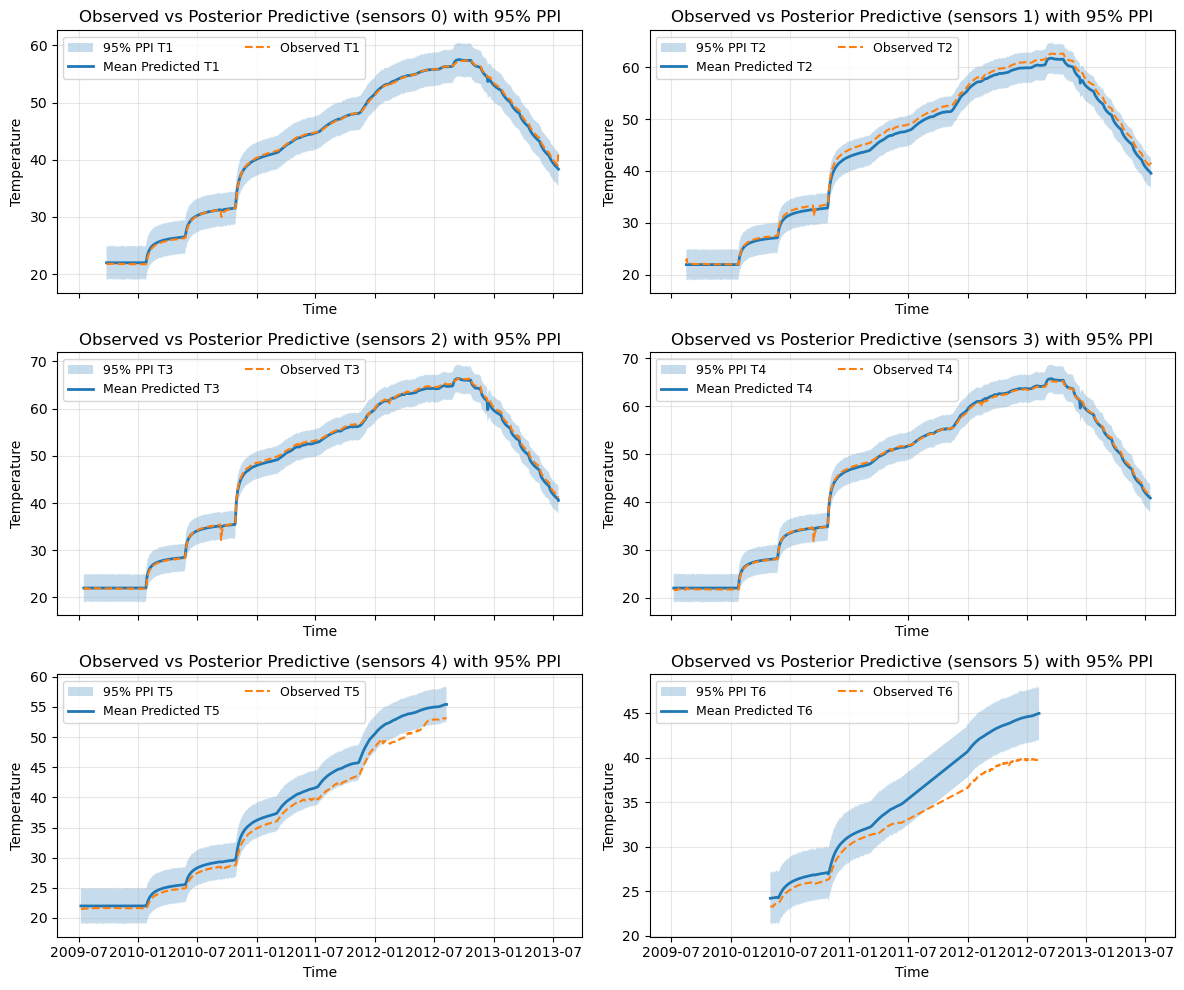

Coverage T1: 100.0%
Coverage T2: 100.0%
Coverage T3: 100.0%
Coverage T4: 100.0%
Coverage T5: 89.6%
Coverage T6: 64.4%


In [582]:

labels = [f"T{i+1}" for i in range(6)]

# Create the plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()
for k, slc in enumerate(sensor_slices):
    ax = axes[k]
    obs_k  = u_obs[slc]
    mean_k = mean_pred[slc]
    low_k  = ppi_low[slc]
    high_k = ppi_high[slc]
    # Use the corresponding time points for this sensor's data
    t_k    = time_points[temperature_data_mask.reshape(temperature_data.shape)[k, :]]


    # dải PPI
    ax.fill_between(t_k, low_k, high_k, alpha=0.25, label=f"95% PPI {labels[k]}")
    # mean
    ax.plot(t_k, mean_k, lw=2, label=f"Mean Predicted {labels[k]}")
    # observed
    ax.plot(t_k, obs_k, ls="--", lw=1.5, label=f"Observed {labels[k]}")

    ax.set_title(f"Observed vs Posterior Predictive (sensors {k}) with 95% PPI")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Coverage theo từng cảm biến (tùy chọn)
for k, slc in enumerate(sensor_slices):
    cover_k = np.mean((u_obs[slc] >= ppi_low[slc]) & (u_obs[slc] <= ppi_high[slc]))
    print(f"Coverage {labels[k]}: {cover_k*100:.1f}%")

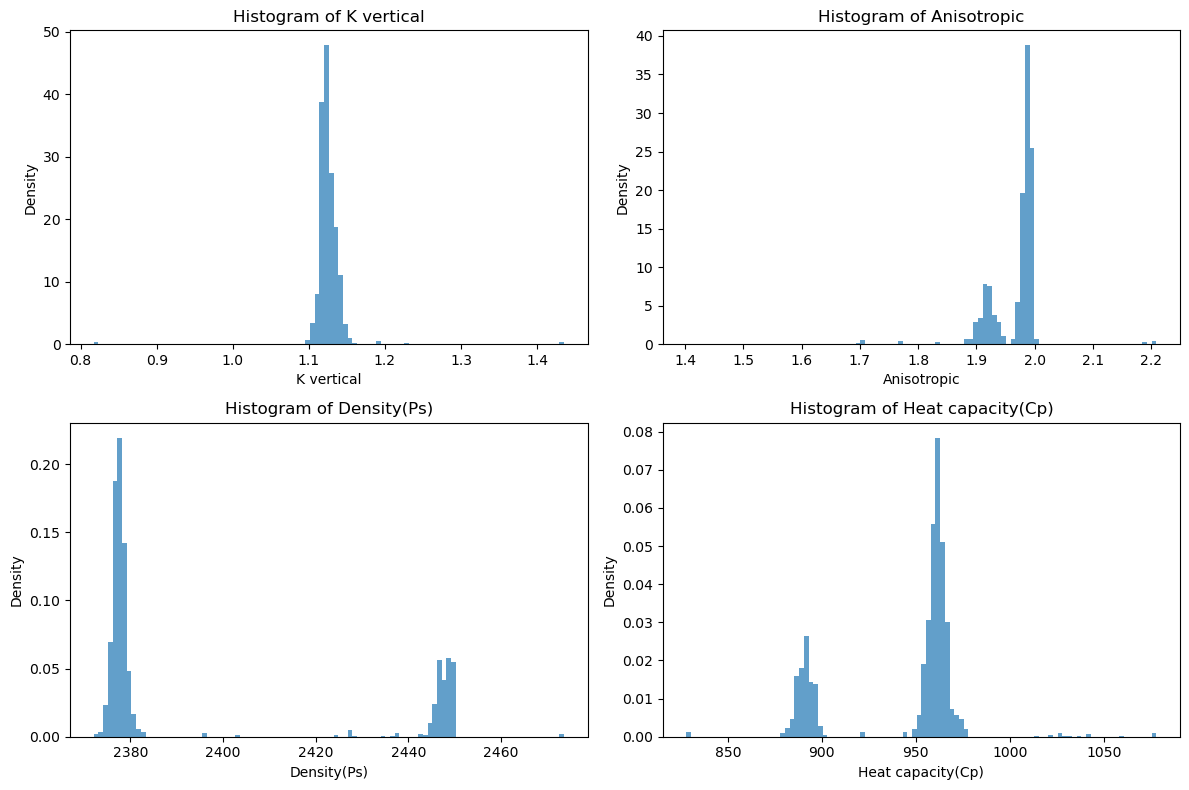

In [584]:
param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"] # Assuming 4 parameters

plt.figure(figsize=(12, 8))
for i in range(samples_params.shape[1]):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    plt.hist(samples_params[:, i], bins=100, density=True, alpha=0.7)
    plt.xlabel(param_names_real[i])
    plt.ylabel("Density")
    plt.title(f"Histogram of {param_names_real[i]}")

plt.tight_layout()
plt.show()

In [ ]:
# ===== emcee_report.py =====
import os, numpy as np, matplotlib.pyplot as plt
import emcee # Import emcee to use its built-in autocorrelation time estimation

# ---------- tiện ích ----------
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def split_chains(samples_3d, split=True):
    # samples_3d: (n_walkers, n_steps, n_dim)
    w, s, d = samples_3d.shape
    if split:
        first = samples_3d[:, :s//2, :]
        second = samples_3d[:, s//2:, :]
        return np.concatenate([first, second], axis=0)
    return samples_3d

def compute_rhat(samples_3d):
    # Split R-hat (Gelman–Rubin)
    chains = split_chains(samples_3d, split=True)
    m, n, d = chains.shape
    # Handle cases where chains are empty or have insufficient steps
    if m == 0 or n < 2:
        return np.full(d, np.nan)
    means = chains.mean(axis=1)               # (m,d)
    variances = chains.var(axis=1, ddof=1)    # (m,d)
    # Handle cases where variance is zero or NaN
    B = n * np.var(means, axis=0, ddof=1)     # (d,)
    W = np.mean(variances, axis=0)            # (d,)
    # Avoid division by zero or NaN
    var_hat = (n-1)/n * W + B/n
    Rhat = np.sqrt(np.divide(var_hat, W, out=np.full_like(var_hat, np.nan), where=W!=0))
    return Rhat


def integrated_autocorr_time_param(x, max_lag=None):
    # Ước lượng tau_int qua FFT + initial positive sequence
    # Add checks for empty or short input
    x = np.asarray(x) - np.mean(x)
    n = x.size
    if n <= 1:
        return np.nan
    if max_lag is None:
        max_lag = min(1000, n//2)
    # Use a more stable method for FFT size calculation
    fft_size = 2**int(np.ceil(np.log2(max(2*n, 2)))) # Ensure at least 2 for log2
    if fft_size > 2**31 - 1: # Check for potential overflow before casting to int
        return np.nan # Or handle error appropriately
    try:
        f = np.fft.rfft(x, n=fft_size)
        acf = np.fft.irfft(f * np.conjugate(f))[:n]
        # Handle case where acf[0] is zero or NaN
        if acf[0] == 0 or np.isnan(acf[0]):
            return np.nan
        acf /= acf[0]
        ssum = 1.0
        for k in range(1, max_lag):
            if acf[k] <= 0:
                break
            ssum += 2.0 * acf[k]
        return max(ssum, 1.0)
    except Exception:
        return np.nan # Handle potential errors during FFT or ACF calculation


def compute_ess(samples_3d):
    # ESS ≈ (n_walkers * n_steps) / tau_int (per-parameter)
    # Calculate ESS for each parameter based on the integrated autocorrelation time
    w, s, d = samples_3d.shape
    total_steps = w * s
    ess = np.zeros(d)
    for j in range(d):
        # Calculate autocorrelation time for each walker and average
        tau_per_walker = []
        for i in range(w):
            tau = integrated_autocorr_time_param(samples_3d[i, :, j])
            if not np.isnan(tau):
                tau_per_walker.append(tau)

        if tau_per_walker:
             # Use the mean of autocorrelation times across walkers
            mean_tau = np.mean(tau_per_walker)
            if mean_tau > 0:
                 ess[j] = total_steps / mean_tau
            else:
                ess[j] = np.nan # Handle zero mean tau
        else:
            ess[j] = np.nan # Handle no valid tau estimates

    return ess

def summarize_param(samples, names=None, quantiles=(0.05, 0.5, 0.95)):
    qs = np.quantile(samples, quantiles, axis=0).T
    means = samples.mean(axis=0)
    sds = samples.std(axis=0, ddof=1)
    out = []
    for j in range(samples.shape[1]):
        out.append({
            "name": names[j] if names else f"param_{j+1}",
            "mean": float(means[j]),
            "sd": float(sds[j]),
            f"q{int(quantiles[0]*100)}": float(qs[j,0]),
            f"q{int(quantiles[1]*100)}": float(qs[j,1]),
            f"q{int(quantiles[2]*100)}": float(qs[j,2]),
        })
    return out

def save_traceplots(samples_3d, out_dir, names=None):
    w, s, d = samples_3d.shape
    for j in range(d):
        plt.figure(figsize=(8,3))
        for i in range(w):
            plt.plot(np.arange(s), samples_3d[i,:,j], linewidth=0.6)
        plt.xlabel("Step"); plt.ylabel(names[j] if names else f"param_{j+1}")
        plt.title(f"Trace: {names[j] if names else f'param_{j+1}'}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"trace_{j+1}.png"), dpi=150)
        plt.close()

def save_density_plots(samples_2d, out_dir, names=None, bins=60):
    n, d = samples_2d.shape
    for j in range(d):
        plt.figure(figsize=(5,3.5))
        plt.hist(samples_2d[:,j], bins=bins, density=True, alpha=0.7)
        plt.xlabel(names[j] if names else f"param_{j+1}")
        plt.ylabel("Density")
        plt.title(f"Posterior density: {names[j] if names else f'param_{j+1}'}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"density_{j+1}.png"), dpi=150)
        plt.close()

def save_pair_scatter(samples_2d, out_dir, names=None, max_pairs=6):
    n, d = samples_2d.shape
    cnt = 0
    for i in range(d):
        for j in range(i+1, d):
            plt.figure(figsize=(4,4))
            plt.plot(samples_2d[:,i], samples_2d[:,j],
                     linestyle='none', marker='.', markersize=1.5, alpha=0.4)
            plt.xlabel(names[i] if names else f"param_{i+1}")
            plt.ylabel(names[j] if names else f"param_{j+1}")
            plt.title("Pairwise scatter")
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"pair_{i+1}_{j+1}.png"), dpi=150)
            plt.close()
            cnt += 1
            if cnt >= max_pairs:
                return

def make_emcee_report(sampler, burn=0, names=None, out_dir="./emcee_report"):
    """
    Tạo báo cáo chẩn đoán từ emcee.EnsembleSampler đã chạy.
    """
    ensure_dir(out_dir); fig_dir = ensure_dir(os.path.join(out_dir, "figs"))

    acceptance_fraction = sampler.acceptance_fraction
    threshold = 2e-1
    good_walkers = np.where(acceptance_fraction >= threshold)[0]
    bad_walkers  = np.where(acceptance_fraction < threshold)[0]
    print(f"🧹 Số walker bị loại bỏ: {len(bad_walkers)} / {n_walkers}")

    # Ensure burn and thin are applied correctly before getting the chain
    chain_b = sampler.get_chain(discard=burn, thin=1, flat=False)[:, good_walkers, :] # Keep original thin step for later flattening
    # Apply additional thinning if needed for analysis, but the code already has thin_step=10
    # So using thin=1 here and then reshaping with the overall thin_step should be correct.
    # Or adjust the discard and thin in get_chain call based on desired post-processing.
    # Given the original code used thin_step=10, let's keep that logic.
    chain_analyzed = sampler.get_chain(discard=burn_in, thin=thin_step, flat=False)[:, good_walkers, :]

    logp  = sampler.get_log_prob()   # (nsteps, nwalkers)

    samples_3d = np.transpose(chain_analyzed, (1,0,2))  # (w,s,d) - use chain_analyzed for diagnostics
    w, s, d = samples_3d.shape
    samples_2d = samples_3d.reshape(w*s, d)
    if names is None: names = [f"theta_{j+1}" for j in range(d)]

    # Diagnostics
    acc_frac = sampler.acceptance_fraction
    try:
        # Use emcee's built-in autocorrelation time estimation
        tau_emcee = sampler.get_autocorr_time(discard=burn, thin=thin_step, quiet=True).tolist()
    except Exception:
        tau_emcee = None
    # Compute ESS based on the estimated autocorrelation time (either emcee's or custom)
    if tau_emcee:
        ess = [(w * s) / t if t > 0 else np.nan for t in tau_emcee]
    else:
        # Fallback to custom ESS calculation if emcee's fails
        ess = compute_ess(samples_3d).tolist()

    rhat = compute_rhat(samples_3d).tolist()
    summary = summarize_param(samples_2d, names=names)

    # Figures
    save_traceplots(samples_3d, fig_dir, names)
    save_density_plots(samples_2d, fig_dir, names)
    save_pair_scatter(samples_2d, fig_dir, names)

    # Report
    report_path = os.path.join(out_dir, "report.md")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write("# Báo cáo chẩn đoán MCMC (emcee)\n\n")
        f.write(f"- Số walker: {sampler.nwalkers}\n")
        f.write(f"- Số bước: {sampler.iteration} (burn-in: {burn})\n\n")

        f.write("## Acceptance fraction\n")
        f.write(f"- mean: {np.mean(acc_frac):.3f}\n")
        f.write(f"- per-walker: {np.array2string(acc_frac, precision=3)}\n\n")

        f.write("## R-hat (split)\n")
        # Handle potential NaN values in R-hat output
        rhat_str = np.array2string(np.array(rhat), precision=3, separator=', ', suppress_small=True)
        f.write(f"- {rhat_str}\n\n")
        f.write("**Gợi ý:** R-hat gần 1 (≤ 1.01–1.05) là tốt.\n\n")

        f.write("## ESS (Effective Sample Size)\n")
        # Handle potential NaN values in ESS output
        ess_str = np.array2string(np.array(ess), precision=3, separator=', ', suppress_small=True)
        f.write(f"- {ess_str}\n\n")

        f.write("## Integrated autocorrelation time (emcee)\n")
        if tau_emcee is None:
            f.write("- Không tính được (chuỗi ngắn) hoặc không ổn định.\n\n")
        else:
            # Handle potential NaN values in tau_emcee output
            tau_emcee_str = np.array2string(np.array(tau_emcee), precision=3, separator=', ', suppress_small=True)
            f.write(f"- tau ≈ {tau_emcee_str}\n\n")

        f.write("## Posterior summary\n")
        f.write("| Param | Mean | SD | q5% | q50% | q95% |\n|---|---:|---:|---:|---:|---:|\n")
        for row in summary:
            f.write(f"| {row['name']} | {row['mean']:.3f} | {row['sd']:.3f} | "
                    f"{row['q5']:.3f} | {row['q50']:.3f} | {row['q95']:.3f} |\n")
        f.write("\n")
        for j in range(d):
            f.write(f"### Trace: {names[j]}\n![trace](figs/trace_{j+1}.png)\n\n")
            f.write(f"### Density: {names[j]}\n![density](figs/density_{j+1}.png)\n\n")
        f.write("### Một số scatter pairwise\n")
        for fn in sorted(os.listdir(fig_dir)):
            if fn.startswith("pair_"):
                f.write(f"![pair](figs/{fn})\n")
    return report_path

# Fix: Provide the correct number of names (5) matching the dimensions of the samples
# Also, burn should match the discard in get_chain calls used for diagnostics
path = make_emcee_report(sampler, burn=3500, names=["theta1","theta2", "theta3", "theta4", "log_sigma_obs"], out_dir="./emcee_report")
print("Report saved at:", path)

N/50 = 3;
tau: [3.00551221 2.65153931 2.59002111 2.9987659  2.56793934]


🧹 Số walker bị loại bỏ: 0 / 60
Report saved at: ./emcee_report1/report.md


In [446]:
# Giả sử bạn đã có chain_good: (n_steps, n_walkers, n_dim)
flat = flatten_chain(chain_good)  # hoặc truyền walkers/thin riêng nếu cần
names = ["log_sigma_obs", "theta1", "theta2", "theta3", "theta4"]  # đặt theo thứ tự cột của bạn

report = normality_report(flat, names)
for r in report:
    print(
        f"{r['name']:>14} | skew={r['skew']:.2f}  kurt={r['kurtosis_fisher']:.2f}  "
        f"K2 p={r['normaltest_K2_p']:.3g}  Shapiro p={r['shapiro_p']:.3g}  "
        f"median={r['median']:.3g}  HDI94=[{r['HDI94_low']:.3g}, {r['HDI94_high']:.3g}]"
    )

qq_and_hist_plots(flat, names)


NameError: name 'flatten_chain' is not defined

In [ ]:
# Define the slices for each sensor based on the temperature_data_mask
# We need to determine the indices in the flattened masked data (u_obs) that correspond to each sensor



Generated sensor_slices: [slice(0, np.int64(1394), None), slice(np.int64(1394), np.int64(2826), None), slice(np.int64(2826), np.int64(4290), None), slice(np.int64(4290), np.int64(5760), None), slice(np.int64(5760), np.int64(6888), None), slice(np.int64(6888), np.int64(7518), None)]
